## Result 1 (epsilon=0.3, c1=0.75, c2=0.02)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv('result_ppo1/training_metrics.csv')
df.head()

,iteration,avg_reward,avg_ep_length,entropy,time_per_iteration,std_reward
0,0,1.909091,60.212121,1.376573,6.939557,1.463985
1,1,2.060606,61.090909,1.370319,7.557680,1.126523
2,2,1.742857,56.828571,1.366339,7.928775,1.338290
3,3,1.710526,53.605263,1.367371,8.427207,1.167721
4,4,2.406250,63.343750,1.337839,7.783551,1.411103


In [3]:
def moving_average(data, window_size=20):
    return data.rolling(window=window_size, min_periods=1).mean()

In [4]:
def plot_and_save(df, column, ylabel, filename, window_size=50):
    plt.figure(figsize=(10, 5))
    ma = moving_average(df[column], window_size)
    plt.plot(df['iteration'], ma, label=f"{column} (MA)")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(f"Moving Average of {ylabel}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()

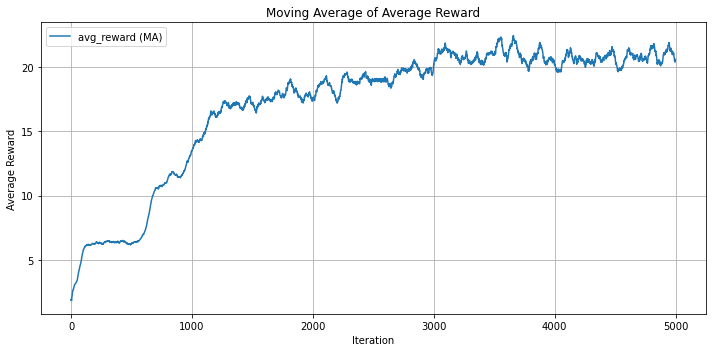

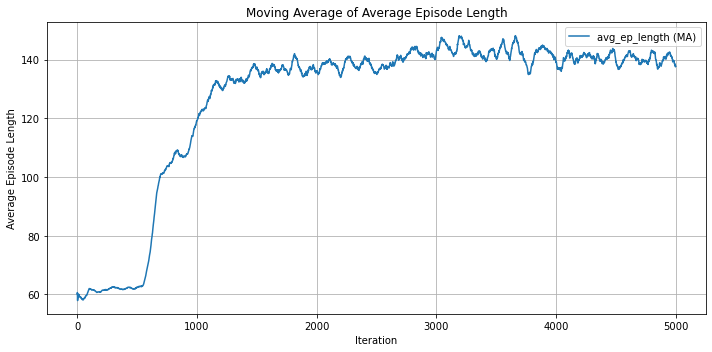

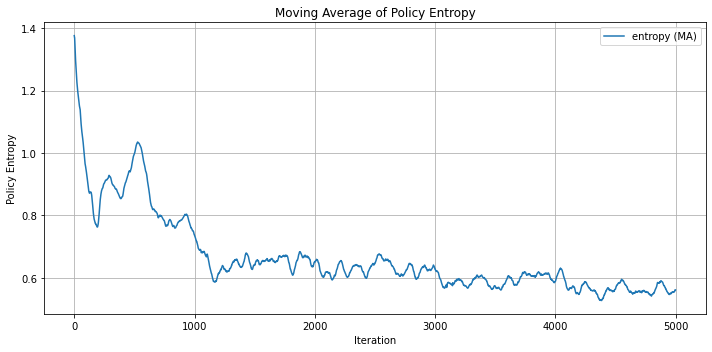

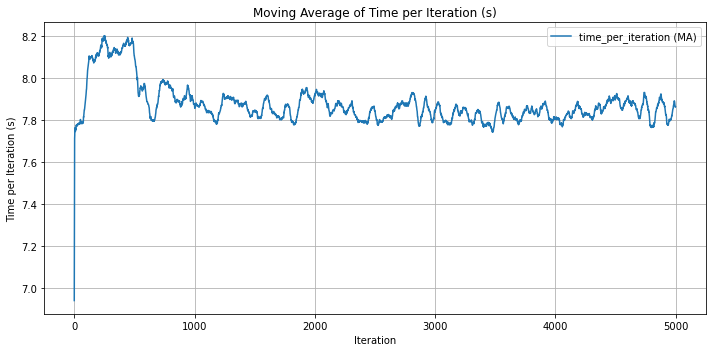

In [5]:
plot_and_save(df, "avg_reward", "Average Reward", "result_ppo1/plot_avg_reward.png")
plot_and_save(df, "avg_ep_length", "Average Episode Length", "result_ppo1/plot_avg_ep_length.png")
plot_and_save(df, "entropy", "Policy Entropy", "result_ppo1/plot_entropy.png")
plot_and_save(df, "time_per_iteration", "Time per Iteration (s)", "result_ppo1/plot_time.png")

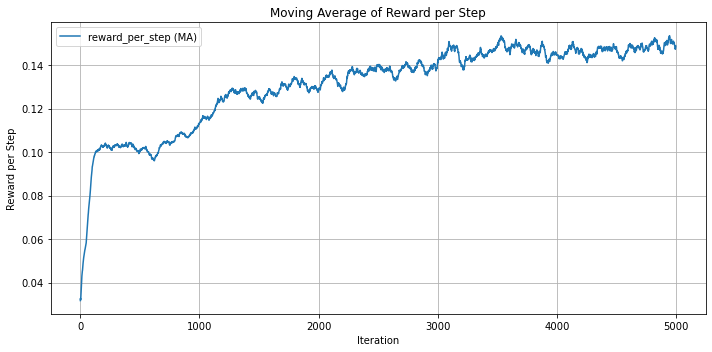

In [6]:
df["reward_per_step"] = df["avg_reward"] / df["avg_ep_length"]
plot_and_save(df, "reward_per_step", "Reward per Step", "result_ppo1/plot_reward_per_step.png")

## Result 2 (epsilon=0.1, c1=0.75, c2=0.1)

In [7]:
df2 = pd.read_csv('result_ppo2/training_metrics.csv')
df2.head()

,iteration,avg_reward,avg_ep_length,entropy,time_per_iteration,std_reward
0,0,1.486486,55.162162,1.383050,7.227812,1.153646
1,1,1.750000,55.694444,1.382523,7.727459,1.361678
2,2,1.805556,56.305556,1.382796,7.860768,1.629919
3,3,1.282051,51.025641,1.382042,7.935216,1.279998
4,4,1.828571,57.514286,1.381319,8.388570,1.423993


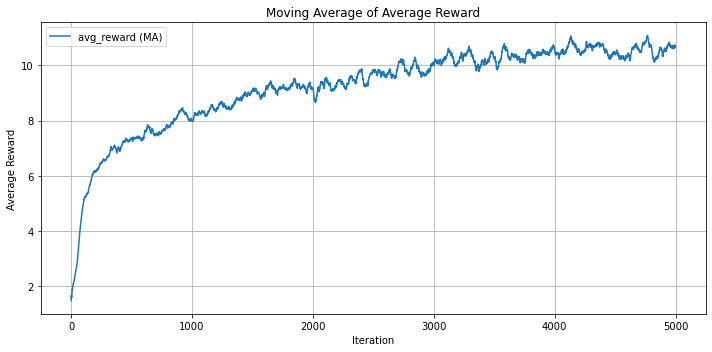

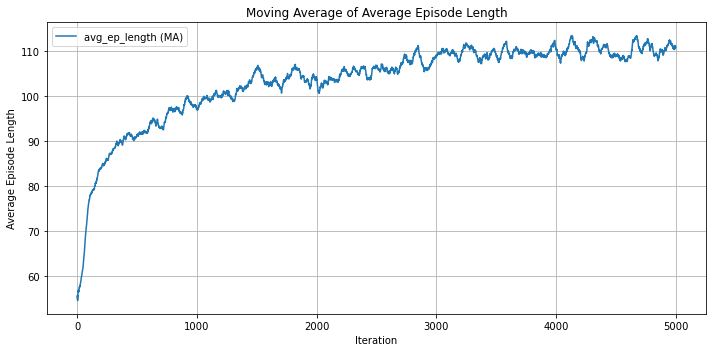

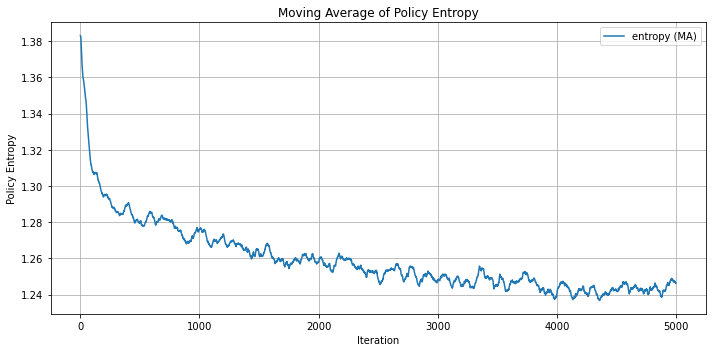

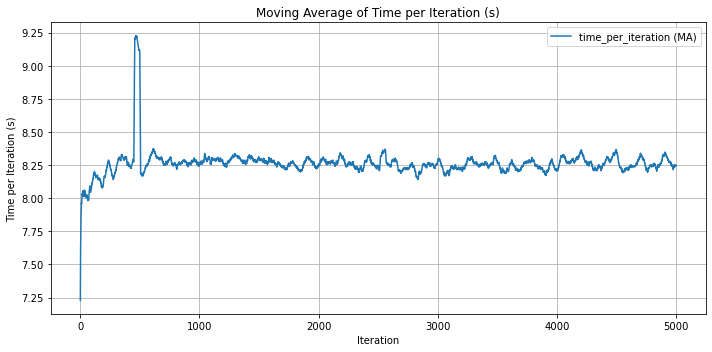

In [8]:
plot_and_save(df2, "avg_reward", "Average Reward", "result_ppo2/plot_avg_reward2.png")
plot_and_save(df2, "avg_ep_length", "Average Episode Length", "result_ppo2/plot_avg_ep_length2.png")
plot_and_save(df2, "entropy", "Policy Entropy", "result_ppo2/plot_entropy2.png")
plot_and_save(df2, "time_per_iteration", "Time per Iteration (s)", "result_ppo2/plot_time2.png")

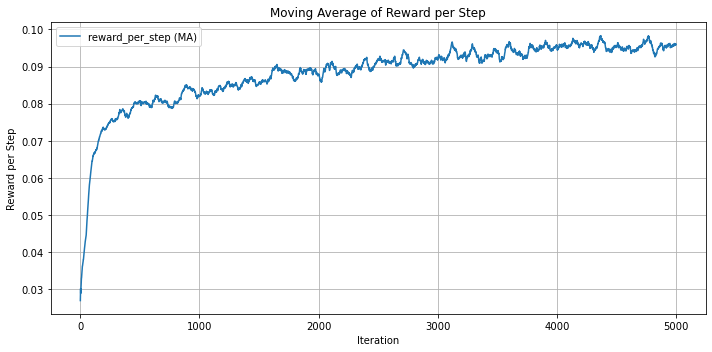

In [9]:
df2["reward_per_step"] = df2["avg_reward"] / df2["avg_ep_length"]
plot_and_save(df2, "reward_per_step", "Reward per Step", "result_ppo2/plot_reward_per_step2.png")

# overall plots

In [10]:
def load_and_prepare(filepath, label, window_size=50):
    df = pd.read_csv(filepath)
    df['label'] = label
    df['reward_ma'] = moving_average(df['avg_reward'], window_size)
    df['length_ma'] = moving_average(df['avg_ep_length'], window_size)
    df['entropy_ma'] = moving_average(df['entropy'], window_size)
    df['time_ma'] = moving_average(df['time_per_iteration'], window_size)
    df['reward_per_step'] = df['avg_reward'] / (df['avg_ep_length'] ) 
    df['reward_per_step_ma'] = moving_average(df['reward_per_step'], window_size)
    return df

def plot_multiple_metrics(dfs, labels, output_path="comparison_plot.png"):
    metrics = {
        'reward_ma': 'Avg Reward (MA)',
        'length_ma': 'Avg Episode Length (MA)',
        'entropy_ma': 'Entropy (MA)',
        'time_ma': 'Time per Iteration (s)',
        'reward_per_step_ma': 'Reward per Step (MA)'
    }

    fig, axs = plt.subplots(len(metrics), 1, figsize=(10, 20))
    for i, (col, title) in enumerate(metrics.items()):
        for df, label in zip(dfs, labels):
            axs[i].plot(df['iteration'], df[col], label=label)
        axs[i].set_title(title)
        axs[i].set_xlabel("Iteration")
        axs[i].set_ylabel(title)
        axs[i].grid(True)
        axs[i].legend()

    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()

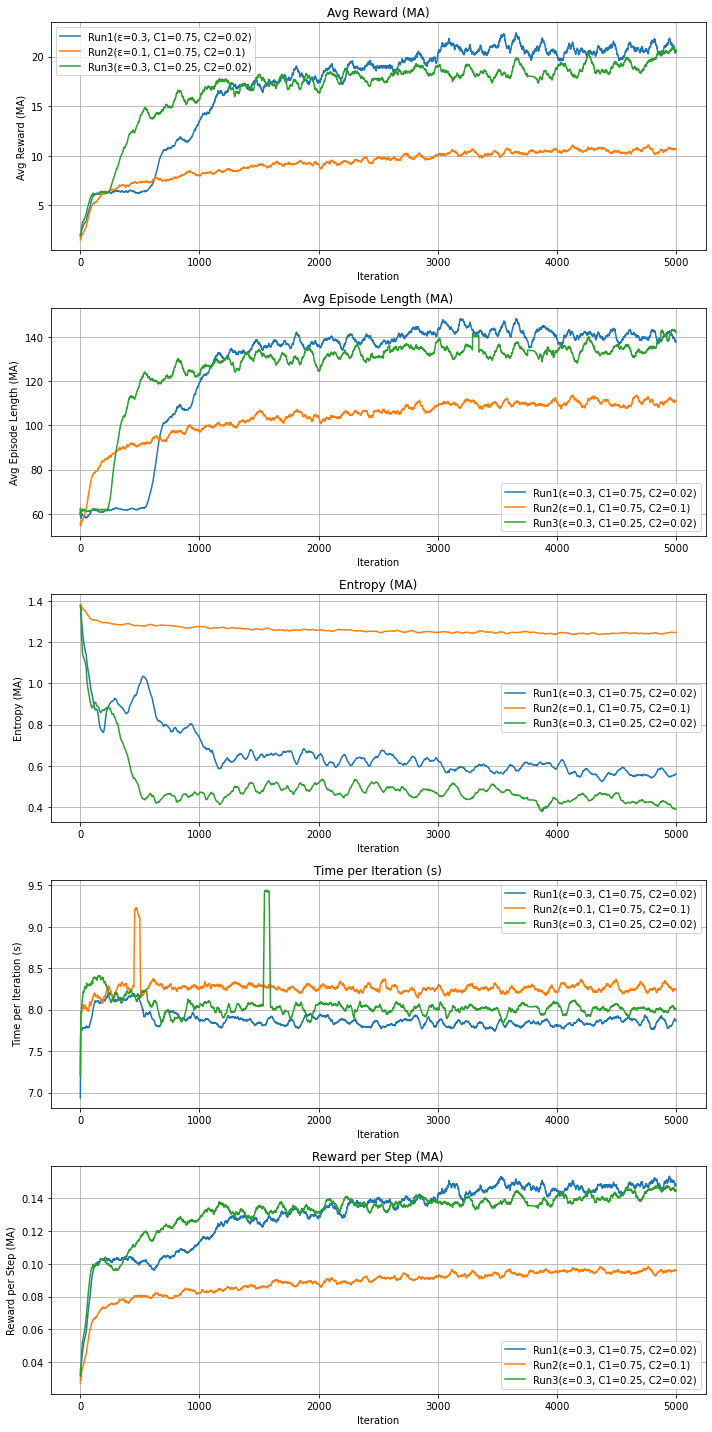

In [15]:
filepaths = [
    "result_ppo1/training_metrics.csv",
    "result_ppo2/training_metrics.csv",
    "result_ppo3/training_metrics2.csv"
]
labels = [
    "Run1(ε=0.3, C1=0.75, C2=0.02)",
    "Run2(ε=0.1, C1=0.75, C2=0.1)",
    "Run3(ε=0.3, C1=0.25, C2=0.02)"
]

dfs = [load_and_prepare(fp, lbl) for fp, lbl in zip(filepaths, labels)]
plot_multiple_metrics(dfs, labels, output_path="comparison_all_metrics.png")